## 1. Data Processing
Here we load the dataset, analyze missing values, and apply preprocessing steps such as encoding categorical variables and standardizing numerical features.

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, matthews_corrcoef
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Imbalanced-learn tools (Unit 3)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Optuna (Unit 2)
import optuna
from optuna.pruners import MedianPruner

# Ensembles (Unit 2)
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier

In [3]:
# Load the multiclass dataset you generated in '001_patterns_into_multiclass.ipynb'
# Replace the path with your actual dataset path
DATA_PATH = "data/ibm_aml_multiclass_clases.csv" 

try:
    df = pd.read_csv(DATA_PATH, low_memory=False)
    print(f"Dataset successfully loaded. Shape: {df.shape}")
except FileNotFoundError:
    print("Please ensure the dataset path is correct.")

# Display basic info
display(df.head(3))

Dataset successfully loaded. Shape: (31898238, 13)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,pattern_base,target_multi
0,2022/09/01 00:17,20,800104D70,20,800104D70,6794.63,US Dollar,6794.63,US Dollar,Reinvestment,0,NaN,0
1,2022/09/01 00:02,3196,800107150,3196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,0,NaN,0
2,2022/09/01 00:17,1208,80010E430,1208,80010E430,1880.23,US Dollar,1880.23,US Dollar,Reinvestment,0,NaN,0


In [4]:
# 1.1 Analyze missing data
print("Missing values per column:\n", df.isnull().sum())

# 1.2 Data Imputation / Cleaning
# Drop redundant columns or columns that directly leak the target
cols_to_drop = ['pattern_base', 'Is Laundering', 'Timestamp', 'Account', 'Account.1', 'From Bank', 'To Bank']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Drop rows where target might be NaN
df_clean = df_clean.dropna(subset=['target_multi'])

print(f"Shape after dropping unnecessary columns: {df_clean.shape}")

Missing values per column:
 Timestamp                    0
From Bank                    0
Account                      0
To Bank                      0
Account.1                    0
Amount Received              0
Receiving Currency           0
Amount Paid                  0
Payment Currency             0
Payment Format               0
Is Laundering                0
pattern_base          31875495
target_multi                 0
dtype: int64
Shape after dropping unnecessary columns: (31898238, 6)


In [5]:
# 1.3 Define Preprocessing Strategy
target = 'target_multi'
X = df_clean.drop(columns=[target])
y = df_clean[target]

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {num_cols}")
print(f"Categorical features: {cat_cols}")

# Create a ColumnTransformer to apply Standardization and One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

Numerical features: ['Amount Received', 'Amount Paid']
Categorical features: ['Receiving Currency', 'Payment Currency', 'Payment Format']


C:\Users\asier\AppData\Local\Temp\ipykernel_23380\2307384993.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


## 2. Imbalance Analysis and Mitigation
The AML dataset is highly imbalanced. The majority class (Normal transactions) vastly outnumbers the minority classes (Laundering patterns). We will apply **Controlled Under-sampling** to make the dataset manageable, followed by **SMOTE** during model training to synthesize minority samples (as seen in Unit 3).

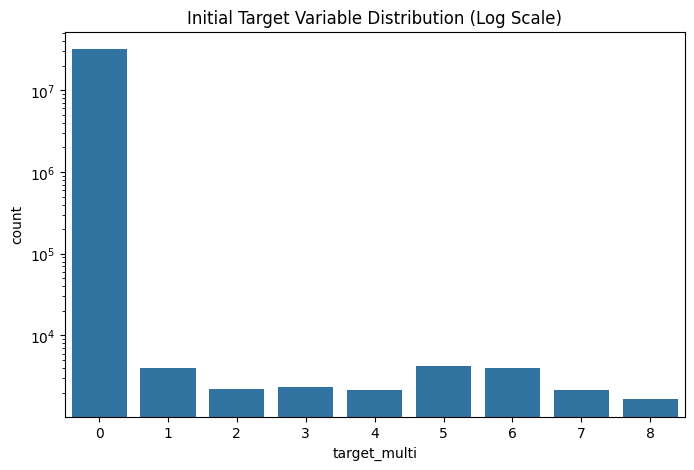

Original Class counts:
 target_multi
0    31875495
5        4289
6        3988
1        3986
3        2315
2        2235
7        2135
4        2128
8        1667
Name: count, dtype: int64

Original Class percentages:
 target_multi
0    99.928701
5     0.013446
6     0.012502
1     0.012496
3     0.007257
2     0.007007
7     0.006693
4     0.006671
8     0.005226
Name: proportion, dtype: float64


In [7]:
# 2.1 Analyze Class Imbalance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target)
plt.title("Initial Target Variable Distribution (Log Scale)")
plt.yscale('log') # Log scale because class 0 is massive
plt.show()

print("Original Class counts:\n", y.value_counts())
print("\nOriginal Class percentages:\n", y.value_counts(normalize=True) * 100)

In [9]:
# 2.2 First Mitigation: Undersampling the massive majority class
# Training on millions of rows is computationally unfeasible locally. 
# We drastically undersample class 0, and keep ALL available records for minority classes.

# 1. Check current counts to build a dynamic dictionary
current_counts = y.value_counts().to_dict()
print(f"Original counts before undersampling: {current_counts}")

# 2. Define dynamic sampling strategy
# Set Class 0 to 100,000 (or whatever fits in your RAM)
sampling_strategy_under = {0: 100000}

# Automatically add the exact maximum available for all other classes
for class_label, count in current_counts.items():
    if class_label != 0:
        sampling_strategy_under[class_label] = count

print(f"\nApplied Undersampling Strategy: {sampling_strategy_under}")

# 3. Apply RandomUnderSampler (Unit 3)
rus = RandomUnderSampler(sampling_strategy=sampling_strategy_under, random_state=42)
X_res, y_res = rus.fit_resample(X, y)

print("\nClass distribution after RandomUnderSampler:")
print(y_res.value_counts())

# 2.3 Train/Test Split (Stratified to maintain proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Original counts before undersampling: {0: 31875495, 5: 4289, 6: 3988, 1: 3986, 3: 2315, 2: 2235, 7: 2135, 4: 2128, 8: 1667}

Applied Undersampling Strategy: {0: 100000, 5: 4289, 6: 3988, 1: 3986, 3: 2315, 2: 2235, 7: 2135, 4: 2128, 8: 1667}

Class distribution after RandomUnderSampler:
target_multi
0    100000
5      4289
6      3988
1      3986
3      2315
2      2235
7      2135
4      2128
8      1667
Name: count, dtype: int64

Training set size: 98194
Testing set size: 24549


## 3. Model Comparison and Hyperparameter Tuning
We will evaluate 4 Ensemble Learning methods (Unit 2):
1. **Random Forest** (Bagging)
2. **AdaBoost** (Boosting)
3. **Gradient Boosting** (Boosting)
4. **LightGBM** (Advanced Boosting)

We use **Optuna** with a `MedianPruner` to efficiently search for hyperparameters. **SMOTE** is applied *inside* the Cross-Validation loop to avoid data leakage.

In [10]:
# 3.1 Define Optuna Objective Function
def objective(trial, model_name):
    # Hyperparameter search space
    if model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'class_weight': 'balanced'
        }
        model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        
    elif model_name == 'AdaBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True)
        }
        model = AdaBoostClassifier(**params, random_state=42)
        
    elif model_name == 'GradientBoosting':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10)
        }
        model = GradientBoostingClassifier(**params, random_state=42)
        
    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'class_weight': 'balanced'
        }
        model = LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)

    # ImbPipeline: Preprocessor -> SMOTE -> Model
    # Applying SMOTE inside the pipeline ensures it's only applied to the training folds during CV
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), 
        ('classifier', model)
    ])
    
    # Cross Validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    
    for step, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_val, y_fold_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        pipeline.fit(X_fold_train, y_fold_train)
        preds = pipeline.predict(X_fold_val)
        
        # We optimize for Macro F1 (crucial for imbalanced multi-class)
        f1 = f1_score(y_fold_val, preds, average='macro')
        f1_scores.append(f1)
        
        # Optuna Pruning (Unit 2)
        trial.report(f1, step)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    return np.mean(f1_scores)

In [11]:
# 3.2 Run Optimization for all models
# Set n_trials to a low number (5) to test if it works, then increase to 20-30 for the final run.
N_TRIALS = 5 
best_models = {}

models_to_test = ['RandomForest', 'AdaBoost', 'GradientBoosting', 'LightGBM']

for model_name in models_to_test:
    print(f"\n--- Optimizing {model_name} ---")
    study = optuna.create_study(
        direction="maximize", 
        pruner=MedianPruner(n_warmup_steps=1) # Applying Pruner as requested
    )
    study.optimize(lambda trial: objective(trial, model_name), n_trials=N_TRIALS)
    
    print(f"Best trial for {model_name}:")
    print(f"  F1-Macro Value: {study.best_value:.4f}")
    print(f"  Params: {study.best_params}")
    
    best_models[model_name] = study.best_params

[I 2026-03-17 00:52:04,265] A new study created in memory with name: no-name-f0518f34-cddb-43ae-93a3-ef3b14a43ffb



--- Optimizing RandomForest ---


[I 2026-03-17 00:53:18,256] Trial 0 finished with value: 0.17617005484106965 and parameters: {'n_estimators': 133, 'max_depth': 20}. Best is trial 0 with value: 0.17617005484106965.
[I 2026-03-17 00:53:36,940] Trial 1 finished with value: 0.1673722554264653 and parameters: {'n_estimators': 135, 'max_depth': 6}. Best is trial 0 with value: 0.17617005484106965.
[I 2026-03-17 00:54:34,696] Trial 2 finished with value: 0.17490572071514576 and parameters: {'n_estimators': 117, 'max_depth': 19}. Best is trial 0 with value: 0.17617005484106965.
[I 2026-03-17 00:54:51,743] Trial 3 finished with value: 0.16736034022798474 and parameters: {'n_estimators': 123, 'max_depth': 6}. Best is trial 0 with value: 0.17617005484106965.
[I 2026-03-17 00:55:19,898] Trial 4 finished with value: 0.17265199117564733 and parameters: {'n_estimators': 123, 'max_depth': 11}. Best is trial 0 with value: 0.17617005484106965.
[I 2026-03-17 00:55:19,900] A new study created in memory with name: no-name-bd5a7c93-5f3b-44

Best trial for RandomForest:
  F1-Macro Value: 0.1762
  Params: {'n_estimators': 133, 'max_depth': 20}

--- Optimizing AdaBoost ---


[I 2026-03-17 00:56:39,194] Trial 0 finished with value: 0.11506671514377893 and parameters: {'n_estimators': 118, 'learning_rate': 0.025123929116333425}. Best is trial 0 with value: 0.11506671514377893.
[I 2026-03-17 00:58:06,306] Trial 1 finished with value: 0.1177263330932727 and parameters: {'n_estimators': 130, 'learning_rate': 0.019679856292367598}. Best is trial 1 with value: 0.1177263330932727.
[I 2026-03-17 00:59:28,887] Trial 2 finished with value: 0.12390433669503381 and parameters: {'n_estimators': 112, 'learning_rate': 0.4132359560263402}. Best is trial 2 with value: 0.12390433669503381.
[I 2026-03-17 01:00:58,163] Trial 3 finished with value: 0.12069179764976652 and parameters: {'n_estimators': 110, 'learning_rate': 0.02594467027250237}. Best is trial 2 with value: 0.12390433669503381.
[I 2026-03-17 01:02:09,395] Trial 4 finished with value: 0.11506671514377893 and parameters: {'n_estimators': 97, 'learning_rate': 0.13091985798758607}. Best is trial 2 with value: 0.123904

Best trial for AdaBoost:
  F1-Macro Value: 0.1239
  Params: {'n_estimators': 112, 'learning_rate': 0.4132359560263402}

--- Optimizing GradientBoosting ---


[W 2026-03-17 01:28:19,114] Trial 0 failed with parameters: {'n_estimators': 61, 'learning_rate': 0.39691762195801383, 'max_depth': 9} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\asier\AppData\Local\Temp\ipykernel_23380\3621368456.py", line 14, in <lambda>
    study.optimize(lambda trial: objective(trial, model_name), n_trials=N_TRIALS)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\asier\AppData\Local\Temp\ipykernel_23380\1358668668.py", line 52, in objective
    pipeline.fit(X_fold_train, y_fold_train)
  File "c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\base.py",

KeyboardInterrupt: 

## 4. Results Discussion
Now we train the final models using the best hyperparameters found by Optuna on the entire training set and evaluate them on the unseen test set.


Classification Report for RandomForest:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     20000
           1       0.14      0.43      0.22       797
           2       0.11      0.11      0.11       447
           3       0.08      0.45      0.13       463
           4       0.07      0.04      0.05       426
           5       0.14      0.03      0.04       858
           6       0.13      0.03      0.04       798
           7       0.04      0.01      0.01       427
           8       0.08      0.04      0.05       333

    accuracy                           0.77     24549
   macro avg       0.20      0.23      0.18     24549
weighted avg       0.84      0.77      0.79     24549


Classification Report for AdaBoost:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94     20000
           1       0.00      0.00      0.00       797
           2       0.07      0.99      0.12       447


c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precisi

,Model,Accuracy,F1-Macro,MCC
0,RandomForest,0.768870,0.179550,0.420668
1,AdaBoost,0.736038,0.119133,0.394946


C:\Users\asier\AppData\Local\Temp\ipykernel_23380\1248981216.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='F1-Macro', palette='viridis')


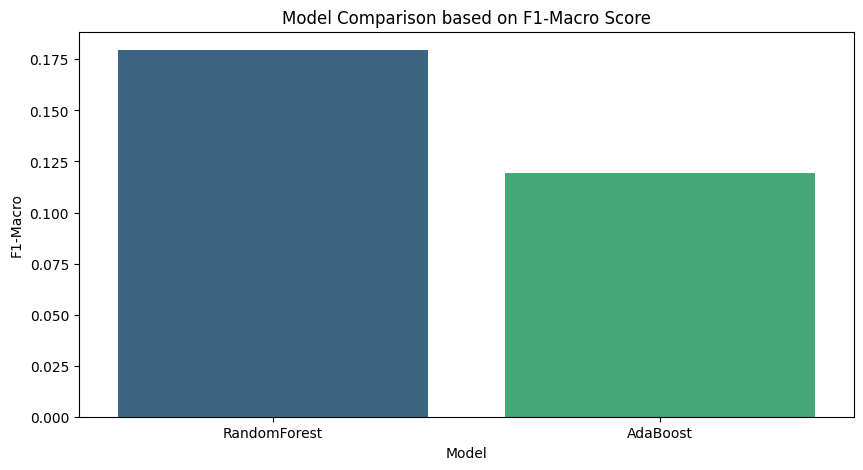

In [12]:
# 4.1 Evaluate Best Models
results_list = []

for model_name, params in best_models.items():
    # Re-instantiate the best model
    if model_name == 'RandomForest':
        model = RandomForestClassifier(**params, random_state=42, n_jobs=-1, class_weight='balanced')
    elif model_name == 'AdaBoost':
        model = AdaBoostClassifier(**params, random_state=42)
    elif model_name == 'GradientBoosting':
        model = GradientBoostingClassifier(**params, random_state=42)
    elif model_name == 'LightGBM':
        model = LGBMClassifier(**params, random_state=42, n_jobs=-1, class_weight='balanced', verbose=-1)
        
    # Final Pipeline
    final_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), 
        ('classifier', model)
    ])
    
    # Train on full training data
    final_pipeline.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = final_pipeline.predict(X_test)
    
    # Collect metrics
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results_list.append({
        'Model': model_name,
        'Accuracy': acc,
        'F1-Macro': f1_macro,
        'MCC': mcc
    })
    
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred))

# 4.2 Display Comparison Table
results_df = pd.DataFrame(results_list).sort_values(by='F1-Macro', ascending=False)
display(results_df)

# Plotting the results
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='F1-Macro', palette='viridis')
plt.title("Model Comparison based on F1-Macro Score")
plt.show()